# Diffractive Lens Optimization — Focusing a Plane Wave

Notebook version of `scripts/lens_optimization_example.py`.  We optimize a **phase-only**
element so that a uniform plane wave forms a bright focal spot at a target pixel after
propagation.

This is a compact end-to-end differentiable optics example: a trainable phase mask,
fixed circular aperture, physics-based propagation, and a scalar focusing loss optimized
with Adam.

### Outline

1. **Imports** for JAX/Optax and the `fouriax.optics` components.
2. **Paths** for saved artifacts.
3. **Helper functions** (circular aperture mask).
4. **Experiment settings** and propagation model.
5. **Optimization objective** and parameter initialization.
6. **Training loop** (gradient descent on phase).
7. **Evaluation** against a hyperbolic-phase focusing reference.
8. **Saved summary and diagnostic plots**.


## 1  Imports

We use JAX for automatic differentiation, Optax for optimization, and `fouriax.optics`
for the optical layers and propagation.  The `focal_spot_loss` utility provides a compact
objective for maximizing energy concentration near a desired focal location.


In [17]:
from __future__ import annotations

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax

from fouriax.optics import (
    AmplitudeMask,
    Field,
    Grid,
    OpticalModule,
    PhaseMask,
    Spectrum,
    focal_spot_loss,
    plan_propagation,
)

%matplotlib inline

## 2  Repository Root and Artifact Paths

The notebook resolves the repository root dynamically so that summary JSON and figures are
saved to the repo-level `artifacts/` directory independent of the kernel's working
location.


In [18]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing scripts/ and src/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
SUMMARY_PATH = ARTIFACTS_DIR / "lens_opt_summary.json"
PLOT_PATH = ARTIFACTS_DIR / "lens_opt_overview.png"

print(f"REPO_ROOT={REPO_ROOT}")
print(f"SUMMARY_PATH={SUMMARY_PATH}")
print(f"PLOT_PATH={PLOT_PATH}")


REPO_ROOT=/Users/liam/fouriax
SUMMARY_PATH=/Users/liam/fouriax/artifacts/lens_opt_summary.json
PLOT_PATH=/Users/liam/fouriax/artifacts/lens_opt_overview.png


## 3  Helper Functions

We define a binary circular aperture mask

$$
A(x,y) = \begin{cases}
1, & x^2 + y^2 \le (D/2)^2, \\
0, & \text{otherwise},
\end{cases}
$$

which limits the active lens area to diameter `D = aperture_diameter_um`.  The optimized
phase is always multiplied by this fixed aperture before propagation.


In [19]:
def circular_aperture(grid: Grid, diameter_um: float) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    r2 = x * x + y * y
    radius = diameter_um / 2.0
    return (r2 <= radius * radius).astype(jnp.float32)


## 4  Fixed Experiment Settings

This section defines the simulation grid, wavelength, propagation distance, and target
focal pixel.  The propagation layer is constructed once using `plan_propagation(mode="auto")`.

The optical pipeline used throughout the notebook is

$$
E_{\mathrm{out}} = \mathcal{P}_z\left\{A(x,y)\,e^{i\phi(x,y)} E_{\mathrm{in}}(x,y)\right\},
$$

where $A(x,y)$ is the circular aperture, $\phi(x,y)$ is the trainable phase, and
$\mathcal{P}_z$ denotes free-space propagation over distance `z = distance_um`.


In [20]:
grid = Grid.from_extent(nx=64, ny=64, dx_um=1.0, dy_um=1.0)
spectrum = Spectrum.from_scalar(0.532)
field_in = Field.plane_wave(grid=grid, spectrum=spectrum)

distance_um = 1000.0
aperture_diameter_um = 48.0
aperture = circular_aperture(grid, diameter_um=aperture_diameter_um)
target_xy = (grid.nx // 2, grid.ny // 2)
window_px = 2

propagator = plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=distance_um,
)


## 5  Optimization Objective and Initialization

### Phase parameterization

We optimize an unconstrained tensor $r(x,y)$ and map it to a bounded phase via

$$
\phi(x,y) = 2\pi\,\sigma(r(x,y)),
$$

where $\sigma$ is the sigmoid.  This keeps the phase in $[0, 2\pi]$ while preserving a
smooth optimization landscape.

### Focusing objective

The propagated field intensity is

$$
I(x,y) = |E_{\mathrm{out}}(x,y)|^2.
$$

`focal_spot_loss(...)` evaluates how well this intensity concentrates around the target
pixel `target_xy`, using a local window of width `window_px`.  Minimizing this loss drives
the phase mask toward a focusing solution.

We initialize the raw phase with small random values and prepare Adam optimizer state.


In [21]:
def loss_fn(raw_phase_map: jnp.ndarray) -> jnp.ndarray:
    phase_limited = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase_map)
    module = OpticalModule(
        layers=(
            PhaseMask(phase_map_rad=phase_limited[None, :, :]),
            AmplitudeMask(amplitude_map=aperture[None, :, :]),
            propagator,
        )
    )
    intensity = module.forward(field_in).intensity()
    return focal_spot_loss(
        intensity=intensity,
        target_xy=target_xy,
        window_px=window_px,
    )

key = jax.random.PRNGKey(0)
phase_map = 0.1 * jax.random.normal(key, (grid.ny, grid.nx))

lr = 0.05
steps = 60
optimizer = optax.adam(lr)
opt_state = optimizer.init(phase_map)
value_and_grad = jax.value_and_grad(loss_fn)


## 6  Run Optimization

We iterate Adam updates for a small number of steps and record the loss history.  The
periodic console prints provide a quick convergence check when running interactively.


In [22]:
history: list[float] = []
for step in range(steps):
    loss, grad = value_and_grad(phase_map)
    updates, opt_state = optimizer.update(grad, opt_state, phase_map)
    phase_map = optax.apply_updates(phase_map, updates)
    history.append(float(loss))
    if step % 20 == 0 or step == steps - 1:
        print(f"step={step:03d} loss={float(loss):.6f}")


step=000 loss=0.944947
step=020 loss=0.847495
step=040 loss=0.838609
step=059 loss=0.835569


## 7  Evaluate Optimized Lens and Hyperbolic-Phase Reference

After optimization, we compute the final focal intensity pattern and compare it to a
classical **hyperbolic-phase lens** reference with phase

$$
\phi_{\mathrm{ref}}(x,y) = -k\left(\sqrt{x^2+y^2+f^2}-f\right),
\qquad k = \frac{2\pi}{\lambda}.
$$

This phase profile equalizes optical path length to a focus at distance `f = distance_um`
(without paraxial approximation), making it a useful baseline for the learned solution.

The notebook compares the optimized and reference center-row intensity profiles.


In [23]:
initial_loss = history[0]
final_loss = history[-1]

final_phase_limited = 2.0 * jnp.pi * jax.nn.sigmoid(phase_map)
final_module = OpticalModule(
    layers=(
        PhaseMask(phase_map_rad=final_phase_limited[None, :, :]),
        AmplitudeMask(amplitude_map=aperture[None, :, :]),
        propagator,
    )
)
final_intensity = np.asarray(final_module.forward(field_in).intensity())[0]
center_intensity = float(final_intensity[target_xy[1], target_xy[0]])
optimized_profile = final_intensity[target_xy[1], :]

x_um, y_um = grid.spatial_grid()
wavelength_um = float(spectrum.wavelengths_um[0])
k = 2.0 * jnp.pi / wavelength_um
hyperbolic_phase = -k * (
    jnp.sqrt(x_um * x_um + y_um * y_um + distance_um**2) - distance_um
)
reference_module = OpticalModule(
    layers=(
        PhaseMask(phase_map_rad=hyperbolic_phase[None, :, :]),
        AmplitudeMask(amplitude_map=aperture[None, :, :]),
        propagator,
    )
)
reference_intensity = np.asarray(reference_module.forward(field_in).intensity())[0]
reference_profile = reference_intensity[target_xy[1], :]


## 8  Save Summary and Figures

The final section writes a compact JSON summary (`lens_opt_summary.json`) and generates an
overview figure containing:

- optimization loss history,
- optimized phase map,
- 2D focal spot intensity, and
- center-row line profile vs the hyperbolic-phase reference.

These outputs are saved in `artifacts/` for script-style reproducibility.


saved: /Users/liam/fouriax/artifacts/lens_opt_summary.json
saved: /Users/liam/fouriax/artifacts/lens_opt_overview.png


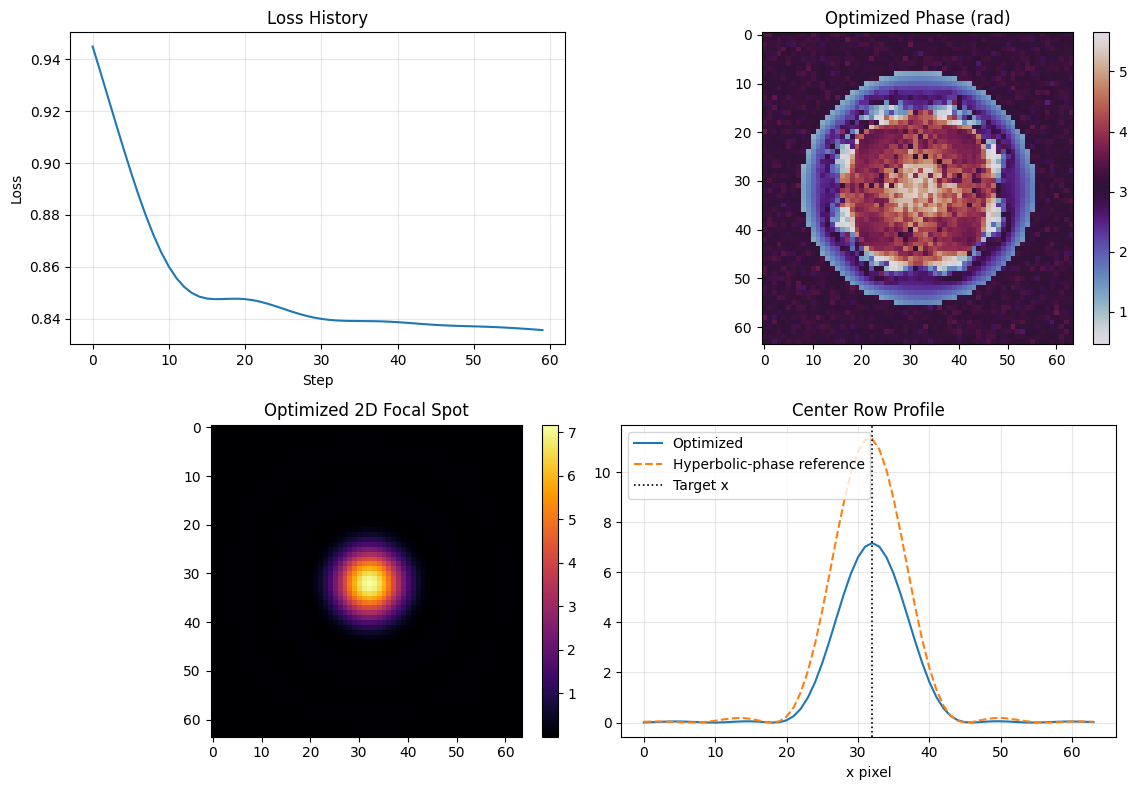

In [24]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

summary = {
    "steps": steps,
    "optimizer": "optax_adam",
    "learning_rate": lr,
    "initial_loss": initial_loss,
    "final_loss": final_loss,
    "improvement": initial_loss - final_loss,
    "target_xy": target_xy,
    "window_px": window_px,
    "center_intensity": center_intensity,
}
with SUMMARY_PATH.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("saved:", SUMMARY_PATH)

optimized_phase = np.asarray(2.0 * jnp.pi * jax.nn.sigmoid(phase_map))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))

axes[0, 0].plot(history)
axes[0, 0].set_title("Loss History")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(alpha=0.3)

phase_im = axes[0, 1].imshow(optimized_phase, cmap="twilight")
axes[0, 1].set_title("Optimized Phase (rad)")
plt.colorbar(phase_im, ax=axes[0, 1], fraction=0.046, pad=0.04)

focus_im = axes[1, 0].imshow(final_intensity, cmap="inferno")
axes[1, 0].set_title("Optimized 2D Focal Spot")
plt.colorbar(focus_im, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].plot(optimized_profile, label="Optimized")
axes[1, 1].plot(reference_profile, label="Hyperbolic-phase reference", linestyle="--")
axes[1, 1].axvline(target_xy[0], color="black", linestyle=":", linewidth=1.2, label="Target x")
axes[1, 1].set_title("Center Row Profile")
axes[1, 1].set_xlabel("x pixel")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=160)
print("saved:", PLOT_PATH)
plt.show()
